# PyTorch로 배우는 Gradient Descent (경사 하강법) 기초 예제

이 노트북은 PyTorch의 자동 미분(Autograd) 기능을 사용하여 가장 기본적인 선형 회귀(Linear Regression) 모델을 학습시키는 과정을 보여줍니다.

**목표**: `y = 2 * x + 1` 이라는 간단한 선형 관계를 데이터를 통해 학습해봅니다.

In [1]:
import torch

## 1. 데이터 준비 (Data Preparation)

- `x_train`: 입력 데이터 (예: 공부 시간)
- `y_train`: 정답 레이블 (예: 시험 점수)

실제 관계는 **y = 2x + 1** 입니다.

In [2]:
x_train = torch.FloatTensor([[1], [2], [3]])
y_train = torch.FloatTensor([[3], [5], [7]])

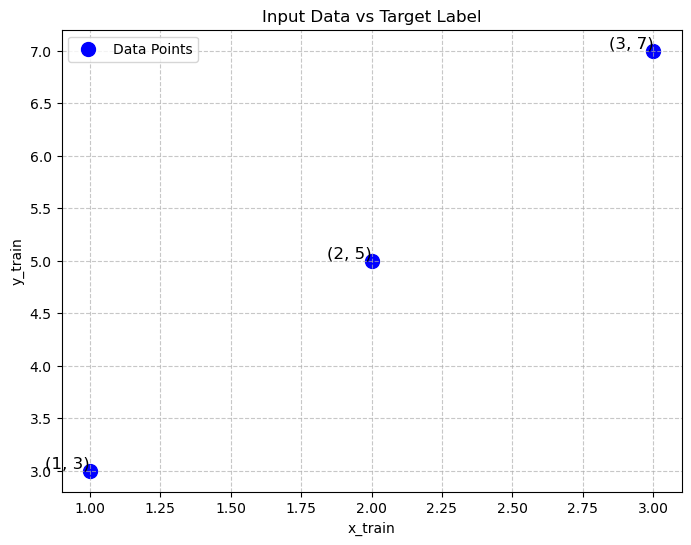

In [5]:
import matplotlib.pyplot as plt

# 데이터 시각화
plt.figure(figsize=(8, 6))
plt.scatter(x_train, y_train, color='blue', label='Data Points', s=100)
plt.title('Input Data vs Target Label')
plt.xlabel('x_train')
plt.ylabel('y_train')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 각 점에 좌표 표시
for x, y in zip(x_train, y_train):
    plt.text(x.item(), y.item(), f'({x.item():.0f}, {y.item():.0f})', 
             fontsize=12, ha='right', va='bottom')

plt.show()

## 2. 모델 초기화 (Model Initialization)

우리가 찾고 싶은 가중치(Weight)와 편향(Bias)을 정의합니다.

- `requires_grad=True`: PyTorch에게 이 변수들의 기울기(Gradient)를 계산하라고 알려줍니다. 이것이 핵심입니다!
- 처음에는 0으로 초기화합니다.

In [7]:
W = torch.zeros(1, requires_grad=True) # 가중치 (기울기)
b = torch.zeros(1, requires_grad=True) # 편향 (절편)

# 학습률 (Learning Rate): 한 번에 얼마나 학습할지 결정하는 보폭
lr = 0.1 

print(f"초기 W: {W.item():.4f}, 초기 b: {b.item():.4f}")

초기 W: 0.0000, 초기 b: 0.0000


## 3. 경사 하강법 반복 (Gradient Descent Loop)

이제 반복적으로 학습을 진행합니다.

1.  **가설 수립 (Hypothesis)**: `H(x) = Wx + b`
2.  **비용 함수 계산 (Cost Function)**: 평균 제곱 오차(MSE)
3.  **기울기 계산 (Backward)**: `cost.backward()`
4.  **파라미터 업데이트**: `W -= lr * gradient`
5.  **기울기 초기화**: `W.grad.zero_()`

In [8]:
# 기록을 저장할 리스트 초기화
losses = []
W_history = []
b_history = []

epochs = 20 # 총 반복 횟수

print("-" * 50)

for epoch in range(epochs + 1):

    # A. 가설 수립 (Hypothesis)
    # 현재의 W와 b를 사용하여 예측값을 계산합니다. (Forward Pass)
    hypothesis = x_train * W + b

    # B. 비용 함수 계산 (Cost Function / Loss)
    # 예측값과 실제값의 차이(오차)를 계산합니다. (MSE)
    cost = torch.mean((hypothesis - y_train) ** 2)

    # --- 기록 저장 ---
    losses.append(cost.item())
    W_history.append(W.item())
    b_history.append(b.item())
    # ----------------

    # C. 기울기 계산 (Gradient Calculation - Backward Pass)
    # cost를 W와 b로 미분하여 기울기를 계산합니다.
    # 이 명령어를 실행하면 W.grad와 b.grad에 기울기 값이 저장됩니다.
    cost.backward()

    # D. 파라미터 업데이트 (Parameter Update)
    # W와 b를 기울기 반대 방향으로 학습률만큼 이동시킵니다.
    # with torch.no_grad(): 업데이트 과정에서는 기울기를 계산하지 않도록 설정합니다.
    with torch.no_grad():
        W -= lr * W.grad
        b -= lr * b.grad

        # E. 기울기 초기화 (Zero Gradients)
        # 다음 반복을 위해 기울기를 0으로 초기화합니다. 
        # 초기화하지 않으면 기울기가 계속 누적되어 엉뚱한 방향으로 학습하게 됩니다.
        W.grad.zero_()
        b.grad.zero_()

    # 로그 출력
    if epoch % 2 == 0:
        print(f'Epoch {epoch:2d}/{epochs} | Cost: {cost.item():.6f} | W: {W.item():.4f} | b: {b.item():.4f}')

print("-" * 50)
print("학습 종료!")
print(f"최종 결과 -> W: {W.item():.4f}, b: {b.item():.4f}")
print("실제 정답 -> W: 2.0000, b: 1.0000")

--------------------------------------------------
Epoch  0/20 | Cost: 27.666666 | W: 2.2667 | b: 1.0000
Epoch  2/20 | Cost: 0.005268 | W: 2.0439 | b: 0.9076
Epoch  4/20 | Cost: 0.001198 | W: 2.0393 | b: 0.9108
Epoch  6/20 | Cost: 0.001087 | W: 2.0374 | b: 0.9151
Epoch  8/20 | Cost: 0.000986 | W: 2.0356 | b: 0.9191
Epoch 10/20 | Cost: 0.000894 | W: 2.0339 | b: 0.9229
Epoch 12/20 | Cost: 0.000811 | W: 2.0323 | b: 0.9266
Epoch 14/20 | Cost: 0.000736 | W: 2.0308 | b: 0.9301
Epoch 16/20 | Cost: 0.000668 | W: 2.0293 | b: 0.9334
Epoch 18/20 | Cost: 0.000606 | W: 2.0279 | b: 0.9366
Epoch 20/20 | Cost: 0.000550 | W: 2.0266 | b: 0.9396
--------------------------------------------------
학습 종료!
최종 결과 -> W: 2.0266, b: 0.9396
실제 정답 -> W: 2.0000, b: 1.0000


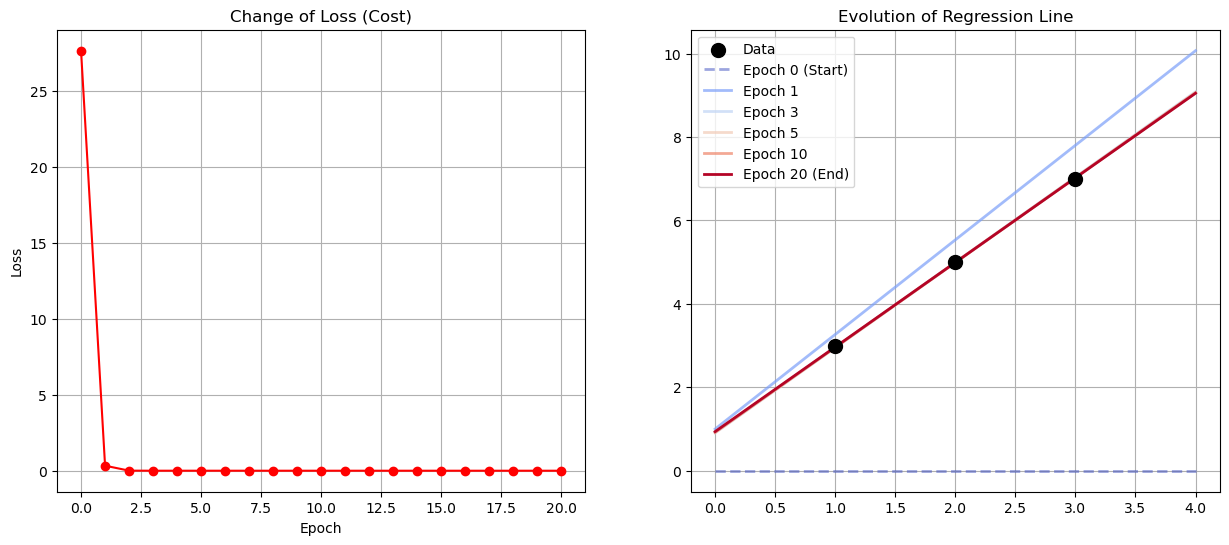

In [11]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 6))

# 1. Loss 변화 그래프
plt.subplot(1, 2, 1)
plt.plot(losses, 'r-o')
plt.title('Change of Loss (Cost)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# 2. 회귀선 변화 그래프
plt.subplot(1, 2, 2)
plt.scatter(x_train, y_train, c='black', label='Data', s=100, zorder=10)

# 주요 에포크의 선 그리기
epochs_to_plot = [0, 1, 3, 5, 10, 20]
x_range = np.linspace(0, 4, 100)

# 색상 맵 변경 (coolwarm: 파랑 -> 빨강)
colors = plt.cm.coolwarm(np.linspace(0, 1, len(epochs_to_plot)))

for i, ep in enumerate(epochs_to_plot):
    if ep < len(W_history):
        w_val = W_history[ep]
        b_val = b_history[ep]
        y_range = w_val * x_range + b_val
        
        # 선 스타일 및 투명도 조정
        if ep == 0:
            linestyle = '--' # 초기값은 점선
            alpha = 0.5
            label = f'Epoch {ep} (Start)'
        elif ep == epochs_to_plot[-1]:
            linestyle = '-'  # 최종값은 실선
            alpha = 1.0
            label = f'Epoch {ep} (End)'
        else:
            linestyle = '-'
            alpha = 0.7
            label = f'Epoch {ep}'
            
        plt.plot(x_range, y_range, label=label, color=colors[i], lw=2, linestyle=linestyle, alpha=alpha)

plt.title('Evolution of Regression Line')
plt.legend()
plt.grid(True)
plt.show()